In [1]:
import numpy as np
import xarray as xr
import cftime
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)


In [3]:
sw_top_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/FSNT_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in sw_top_19['time'].values])
sw_top_19 = sw_top_19.assign_coords(time=shifted_time_19)
sw_top_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/FSNT_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in sw_top_19_c['time'].values])
sw_top_19_c = sw_top_19_c.assign_coords(time=shifted_time_19_c)
sw_top_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/FSNT_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in sw_top_22['time'].values])
sw_top_22 = sw_top_22.assign_coords(time=shifted_time_22)
sw_top_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/FSNT_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in sw_top_24['time'].values])
sw_top_24 = sw_top_24.assign_coords(time=shifted_time_24)
sw_top_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/FSNT_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in sw_top_1825_17tg['time'].values])
sw_top_1825_17tg = sw_top_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
sw_top_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/FSNT_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in sw_top_1825['time'].values])
sw_top_1825 = sw_top_1825.assign_coords(time=shifted_time_1825)
sw_top_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/FSNT_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in sw_top_1tg['time'].values])
sw_top_1tg = sw_top_1tg.assign_coords(time=shifted_time_1tg)
sw_top_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/FSNT_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in sw_top_1pr['time'].values])
sw_top_1pr = sw_top_1pr.assign_coords(time=shifted_time_1pr)
sw_top_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/FSNT_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in sw_top_60tg['time'].values])
sw_top_60tg = sw_top_60tg.assign_coords(time=shifted_time_60tg)

In [4]:
baseline_maps = sw_top_19["FSNT"].sel(time=slice("1986-01", "1990-12")).groupby("time.month").mean(dim="time")
sw_top_anom_maps_19 = sw_top_19["FSNT"].groupby("time.month") - baseline_maps
sw_top_anom_maps_19 = sw_top_anom_maps_19.sel(time=slice("1991-01", "1996-01"))
sw_top_anom_maps_19_c = sw_top_19_c["FSNT"].groupby("time.month") - baseline_maps
sw_top_anom_maps_22 = sw_top_22["FSNT"].groupby("time.month") - baseline_maps
sw_top_anom_maps_24 = sw_top_24["FSNT"].groupby("time.month") - baseline_maps
sw_top_anom_maps_1825 = sw_top_1825["FSNT"].groupby("time.month") - baseline_maps
sw_top_anom_maps_1825_17tg = sw_top_1825_17tg["FSNT"].groupby("time.month") - baseline_maps
sw_top_anom_maps_1pr = sw_top_1pr["FSNT"].groupby("time.month") - baseline_maps
sw_top_anom_maps_1tg = sw_top_1tg["FSNT"].groupby("time.month") - baseline_maps
sw_top_anom_maps_60tg = sw_top_60tg["FSNT"].groupby("time.month") - baseline_maps

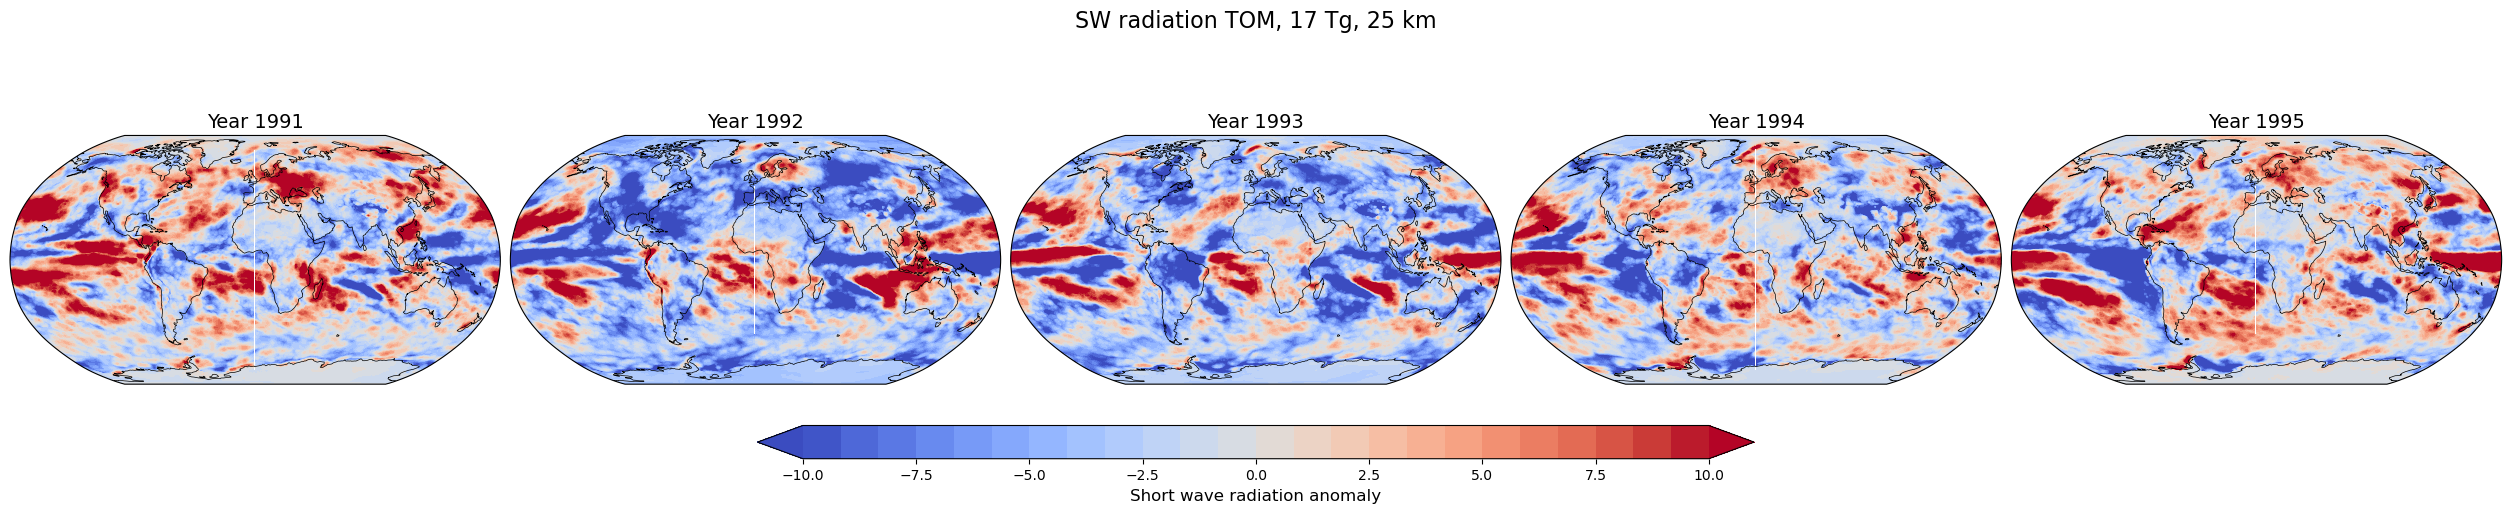

In [5]:
sw_top_anom_years = sw_top_anom_maps_24.resample(time="YS").mean()

levels = np.linspace(-10, 10, 25) 

fig, axs = plt.subplots(1, 5, figsize=(25, 5), 
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                        constrained_layout=True)

for i, t in enumerate(sw_top_anom_years["time"][:5]):
    ax = axs[i]
    data_for_year = sw_top_anom_years.sel(time=t)
    year_str = str(t.dt.year.values)

    ax.coastlines(resolution='110m', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', alpha=0.1)
    ax.set_global()

    cf = ax.contourf(
        sw_top_anom_years.lon, 
        sw_top_anom_years.lat, 
        data_for_year, 
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap='coolwarm',
        extend='both' 
    )   

    ax.set_title(f"Year {year_str}", fontsize=14)

cbar = fig.colorbar(cf, ax=axs, orientation='horizontal', pad=0.1, shrink=0.4, aspect=30)
cbar.set_label('Short wave radiation anomaly', fontsize=12)
plt.suptitle('SW radiation TOM, 17 Tg, 25 km', fontsize=16)
plt.show()

In [6]:
trop_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/TROP_P_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in trop_19['time'].values])
trop_19 = trop_19.assign_coords(time=shifted_time_19)
trop_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/TROP_P_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in trop_19_c['time'].values])
trop_19_c = trop_19_c.assign_coords(time=shifted_time_19_c)
trop_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/TROP_P_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in trop_22['time'].values])
trop_22 = trop_22.assign_coords(time=shifted_time_22)
trop_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/TROP_P_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in trop_24['time'].values])
trop_24 = trop_24.assign_coords(time=shifted_time_24)
trop_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/TROP_P_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in trop_1825_17tg['time'].values])
trop_1825_17tg = trop_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
trop_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/TROP_P_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in trop_1825['time'].values])
trop_1825 = trop_1825.assign_coords(time=shifted_time_1825)
trop_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/TROP_P_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in trop_1tg['time'].values])
trop_1tg = trop_1tg.assign_coords(time=shifted_time_1tg)
trop_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/TROP_P_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in trop_1pr['time'].values])
trop_1pr = trop_1pr.assign_coords(time=shifted_time_1pr)
trop_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/TROP_P_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in trop_60tg['time'].values])
trop_60tg = trop_60tg.assign_coords(time=shifted_time_60tg)

In [7]:
lat = sw_top_19["lat"]
weighted_lat_19 = np.cos(np.deg2rad(lat))
lat = sw_top_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat))
lat = sw_top_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat))
lat = sw_top_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat))
lat = sw_top_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat))
lat = sw_top_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat))
lat = sw_top_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat))
lat = sw_top_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat))
lat = sw_top_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat))

In [8]:
tropopause = trop_19["TROP_P"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
tropopause_22 = trop_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
tropopause_19_c = trop_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
tropopause_24 = trop_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
tropopause_1825 = trop_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
tropopause_1825_17tg = trop_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
tropopause_1tg = trop_1tg["TROP_P"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
tropopause_1pr= trop_1pr["TROP_P"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
tropopause_60tg= trop_60tg["TROP_P"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])

In [9]:
p_lev = tropopause * 0.01
p_lev_22 = tropopause_22 * 0.01
p_lev_19_c = tropopause_19_c * 0.01
p_lev_24 = tropopause_24 * 0.01
p_lev_1825 = tropopause_1825 * 0.01
p_lev_1825_17tg = tropopause_1825_17tg * 0.01
p_lev_1tg = tropopause_1tg * 0.01
p_lev_1pr = tropopause_1pr * 0.01
p_lev_60tg = tropopause_60tg * 0.01

In [10]:
mmr_SULFATE_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/mmr_SULFATE_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in mmr_SULFATE_19['time'].values])
mmr_SULFATE_19 = mmr_SULFATE_19.assign_coords(time=shifted_time_19)
mmr_SULFATE_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in mmr_SULFATE_19_c['time'].values])
mmr_SULFATE_19_c = mmr_SULFATE_19_c.assign_coords(time=shifted_time_19_c)
mmr_SULFATE_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in mmr_SULFATE_22['time'].values])
mmr_SULFATE_22 = mmr_SULFATE_22.assign_coords(time=shifted_time_22)
mmr_SULFATE_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in mmr_SULFATE_24['time'].values])
mmr_SULFATE_24 = mmr_SULFATE_24.assign_coords(time=shifted_time_24)
mmr_SULFATE_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in mmr_SULFATE_1825_17tg['time'].values])
mmr_SULFATE_1825_17tg = mmr_SULFATE_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
mmr_SULFATE_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in mmr_SULFATE_1825['time'].values])
mmr_SULFATE_1825 = mmr_SULFATE_1825.assign_coords(time=shifted_time_1825)
mmr_SULFATE_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in mmr_SULFATE_1tg['time'].values])
mmr_SULFATE_1tg = mmr_SULFATE_1tg.assign_coords(time=shifted_time_1tg)
mmr_SULFATE_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in mmr_SULFATE_1pr['time'].values])
mmr_SULFATE_1pr = mmr_SULFATE_1pr.assign_coords(time=shifted_time_1pr)
mmr_SULFATE_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/mmr_SULFATE_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in mmr_SULFATE_60tg['time'].values])
mmr_SULFATE_60tg = mmr_SULFATE_60tg.assign_coords(time=shifted_time_60tg)

In [11]:
Ms = 32.065 
Mair = 28.96  # dry air
Matmos = 5.3 * 10**21
K = (Ms/Mair) * Matmos *10**(-12)
M_strat_air = 0.099 * Matmos   #9.9% of the total mass of the atmosphere
Mo = 15.999
Mso4 = Ms + (4 * Mo)
c = Ms/Mso4

In [12]:
lev_pa = mmr_SULFATE_19.lev * 100
delta_p = np.diff(lev_pa.values, append=lev_pa.values[-1] + (lev_pa.values[-1]-lev_pa.values[-2]))
air_mass_per_m2 = np.abs(delta_p) / 9.81
M_layer_da = xr.DataArray(air_mass_per_m2, coords=[mmr_SULFATE_19.lev], dims=['lev'])

so4_kg_m2 = (mmr_SULFATE_19["mmr_SULFATE"] * M_layer_da).sum(dim="lev")
base_so4 = so4_kg_m2.sel(time=slice("1986-01", "1990-12")).groupby("time.month").mean(dim="time")
so4_anom = so4_kg_m2.groupby("time.month") - base_so4
so4_anom = so4_anom.sel(time=slice("1991-01", "1996-01"))
so4_map_data = so4_anom * 1e6

In [13]:
lev_pa = mmr_SULFATE_19_c.lev * 100
delta_p = np.diff(lev_pa.values, append=lev_pa.values[-1] + (lev_pa.values[-1]-lev_pa.values[-2]))
air_mass_per_m2 = np.abs(delta_p) / 9.81
M_layer_da = xr.DataArray(air_mass_per_m2, coords=[mmr_SULFATE_19_c.lev], dims=['lev'])

so4_kg_m2 = (mmr_SULFATE_19_c["mmr_SULFATE"] * M_layer_da).sum(dim="lev")
so4_anom = so4_kg_m2.groupby("time.month") - base_so4
so4_map_data_19_c = so4_anom * 1e6

In [14]:
lev_pa = mmr_SULFATE_24.lev * 100
delta_p = np.diff(lev_pa.values, append=lev_pa.values[-1] + (lev_pa.values[-1]-lev_pa.values[-2]))
air_mass_per_m2 = np.abs(delta_p) / 9.81
M_layer_da = xr.DataArray(air_mass_per_m2, coords=[mmr_SULFATE_24.lev], dims=['lev'])

so4_kg_m2 = (mmr_SULFATE_24["mmr_SULFATE"] * M_layer_da).sum(dim="lev")
so4_anom = so4_kg_m2.groupby("time.month") - base_so4
so4_map_data_24 = so4_anom * 1e6

In [15]:
lev_pa = mmr_SULFATE_1825.lev * 100
delta_p = np.diff(lev_pa.values, append=lev_pa.values[-1] + (lev_pa.values[-1]-lev_pa.values[-2]))
air_mass_per_m2 = np.abs(delta_p) / 9.81
M_layer_da = xr.DataArray(air_mass_per_m2, coords=[mmr_SULFATE_1825.lev], dims=['lev'])

so4_kg_m2 = (mmr_SULFATE_1825["mmr_SULFATE"] * M_layer_da).sum(dim="lev")
so4_anom = so4_kg_m2.groupby("time.month") - base_so4
so4_map_data_1825 = so4_anom * 1e6

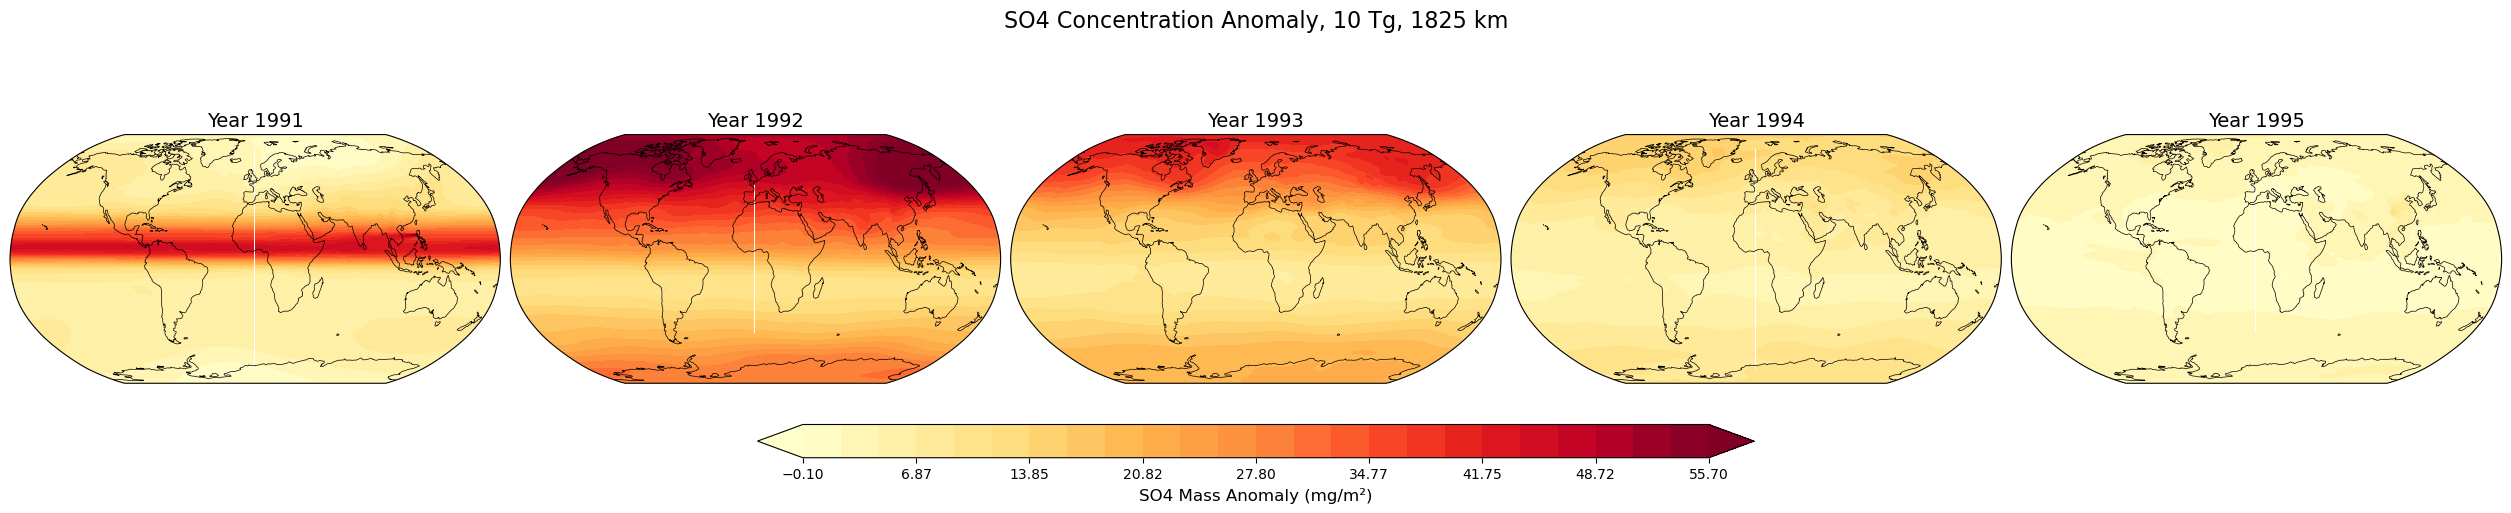

In [16]:
so4_years = so4_map_data_1825.resample(time="YS").mean()

v_max = float(so4_years.max() * 0.9) 
v_min = -0.1 
levels = np.linspace(v_min, v_max, 25)

fig, axs = plt.subplots(1, 5, figsize=(25, 5), 
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                        constrained_layout=True)

for i, t in enumerate(so4_years["time"][:5]):
    ax = axs[i]
    data_for_year = so4_years.sel(time=t)
    year_str = str(t.dt.year.values)

    ax.coastlines(resolution='110m', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', alpha=0.1)
    ax.set_global()

    cf = ax.contourf(
        so4_years.lon, 
        so4_years.lat, 
        data_for_year, 
        transform=ccrs.PlateCarree(), 
        levels=levels,
        cmap='YlOrRd', 
        extend='both' 
    )   

    ax.set_title(f"Year {year_str}", fontsize=14)

cbar = fig.colorbar(cf, ax=axs, orientation='horizontal', pad=0.1, shrink=0.4, aspect=30)
cbar.set_label('SO4 Mass Anomaly (mg/m²)', fontsize=12)
plt.suptitle('SO4 Concentration Anomaly, 10 Tg, 1825 km', fontsize=16)
plt.show()

In [17]:
aod_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/AOD_VIS_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in aod_19['time'].values])
aod_19 = aod_19.assign_coords(time=shifted_time_19)
aod_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/AOD_VIS_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in aod_19_c['time'].values])
aod_19_c = aod_19_c.assign_coords(time=shifted_time_19_c)
aod_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in aod_22['time'].values])
aod_22 = aod_22.assign_coords(time=shifted_time_22)
aod_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in aod_24['time'].values])
aod_24 = aod_24.assign_coords(time=shifted_time_24)
aod_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in aod_1825_17tg['time'].values])
aod_1825_17tg = aod_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
aod_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in aod_1825['time'].values])
aod_1825 = aod_1825.assign_coords(time=shifted_time_1825)
aod_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in aod_1tg['time'].values])
aod_1tg = aod_1tg.assign_coords(time=shifted_time_1tg)
aod_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/AOD_VIS_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in aod_1pr['time'].values])
aod_1pr = aod_1pr.assign_coords(time=shifted_time_1pr)
aod_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/AOD_VIS_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in aod_60tg['time'].values])
aod_60tg = aod_60tg.assign_coords(time=shifted_time_60tg)

In [18]:
day_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/DAYFOC_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in day_19['time'].values])
day_19 = day_19.assign_coords(time=shifted_time_19)
day_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/DAYFOC_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in day_19_c['time'].values])
day_19_c = day_19_c.assign_coords(time=shifted_time_19_c)
day_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/DAYFOC_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in day_22['time'].values])
day_22 = day_22.assign_coords(time=shifted_time_22)
day_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/DAYFOC_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in day_24['time'].values])
day_24 = day_24.assign_coords(time=shifted_time_24)
day_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/DAYFOC_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in day_1825_17tg['time'].values])
day_1825_17tg = day_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
day_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/DAYFOC_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in day_1825['time'].values])
day_1825 = day_1825.assign_coords(time=shifted_time_1825)
day_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/DAYFOC_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in day_1tg['time'].values])
day_1tg = day_1tg.assign_coords(time=shifted_time_1tg)
day_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/DAYFOC_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in day_1pr['time'].values])
day_1pr = day_1pr.assign_coords(time=shifted_time_1pr)
day_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/DAYFOC_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in day_60tg['time'].values])
day_60tg = day_60tg.assign_coords(time=shifted_time_60tg)

In [19]:
aod500 = "AOD_VIS"  # AOD at 0.442-0.625um
daylight = "DAYFOC"  # Fraction of day in the month

mapped_aod = aod_19[aod500]/ day_19[daylight]
mapped_aod = mapped_aod.sel(time=slice("1991-01", "1996-01"))
mapped_aod_22 = aod_22[aod500] / day_22[daylight]
mapped_aod_19_c = aod_19_c[aod500] / day_19_c[daylight]
mapped_aod_24 = aod_24[aod500] / day_24[daylight]
mapped_aod_1825 = aod_1825[aod500] / day_1825[daylight]
mapped_aod_1825_17tg = aod_1825_17tg[aod500] / day_1825_17tg[daylight]
mapped_aod_1tg = aod_1tg[aod500] / day_1tg[daylight]
mapped_aod_1pr = aod_1pr[aod500] / day_1pr[daylight]
mapped_aod_60tg = aod_60tg[aod500] / day_60tg[daylight]

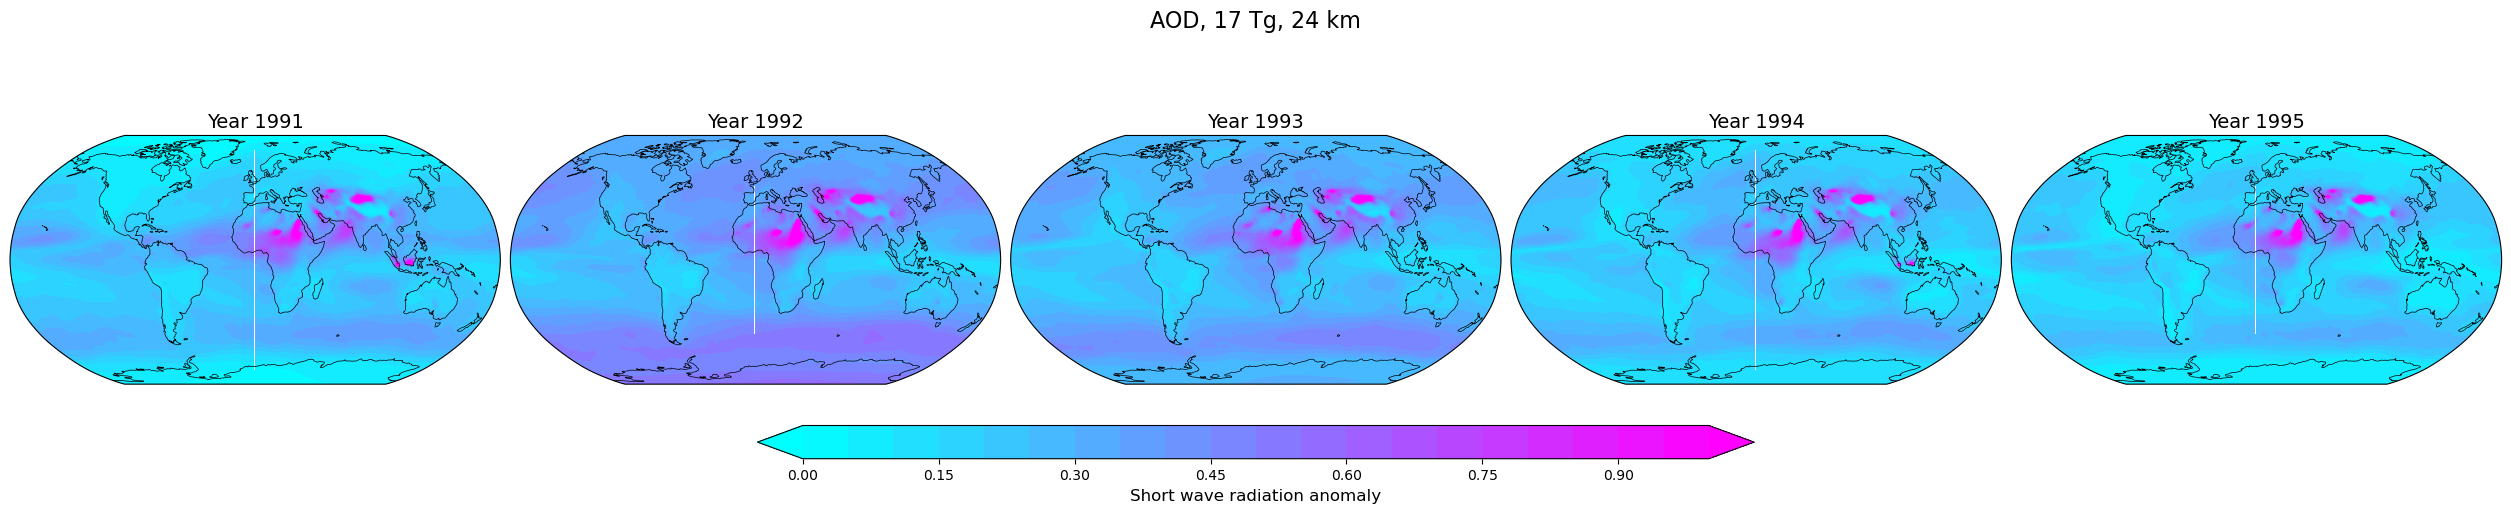

In [20]:
aod_mapped = mapped_aod_24.resample(time="YS").mean()

levels = np.linspace(0, 1, 21) 

fig, axs = plt.subplots(1, 5, figsize=(25, 5), 
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                        constrained_layout=True)

for i, t in enumerate(aod_mapped["time"][:5]):
    ax = axs[i]
    data_for_year = aod_mapped.sel(time=t)
    year_str = str(t.dt.year.values)

    ax.coastlines(resolution='110m', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', alpha=0.1)
    ax.set_global()

    cf = ax.contourf(
        aod_mapped.lon, 
        aod_mapped.lat, 
        data_for_year, 
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap='cool',
        extend='both' 
    )   

    ax.set_title(f"Year {year_str}", fontsize=14)

cbar = fig.colorbar(cf, ax=axs, orientation='horizontal', pad=0.1, shrink=0.4, aspect=30)
cbar.set_label('Short wave radiation anomaly', fontsize=12)
plt.suptitle('AOD, 17 Tg, 24 km', fontsize=16)
plt.show()

In [21]:
ts_aod = aod_19[aod500].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
daylight_monthly = day_19[daylight].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
ts_aod = ts_aod / daylight_monthly
#ts_aod = ts_aod.resample(time="1YE").mean()
ts_aod_22 = aod_22[aod500].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
daylight_monthly_22 = day_22[daylight].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
ts_aod_22 = ts_aod_22 / daylight_monthly_22
ts_aod_19_c = aod_19_c[aod500].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
daylight_monthly_19_c = day_19_c[daylight].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
ts_aod_19_c = ts_aod_19_c / daylight_monthly_19_c
ts_aod_24 = aod_24[aod500].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
daylight_monthly_24= day_24[daylight].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
ts_aod_24 = ts_aod_24 / daylight_monthly_24
ts_aod_1825 =aod_1825[aod500].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
daylight_monthly_1825= day_1825[daylight].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
ts_aod_1825 = ts_aod_1825 / daylight_monthly_1825
ts_aod_1825_17tg = aod_1825_17tg[aod500].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
daylight_monthly_1825_17tg= day_1825_17tg[daylight].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
ts_aod_1825_17tg = ts_aod_1825_17tg / daylight_monthly_1825_17tg
ts_aod_1tg = aod_1tg[aod500].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
daylight_monthly_1tg= day_1tg[daylight].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
ts_aod_1tg = ts_aod_1tg / daylight_monthly_1tg
ts_aod_1pr = aod_1pr[aod500].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
daylight_monthly_1pr= day_1pr[daylight].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
ts_aod_1pr = ts_aod_1pr / daylight_monthly_1pr
ts_aod_60tg = aod_60tg[aod500].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
daylight_monthly_60tg= day_60tg[daylight].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
ts_aod_60tg = ts_aod_60tg / daylight_monthly_60tg

In [22]:
pre_eruption = ts_aod.sel(time=slice("1986-01", "1990-12"))
base = pre_eruption.groupby("time.month").mean("time")
anomalies = pre_eruption.groupby("time.month") - base

aod_anom = ts_aod.groupby("time.month") - base
aod_anom_22 = ts_aod_22.groupby("time.month") - base
aod_anom_19_c = ts_aod_19_c.groupby("time.month") - base
aod_anom_24 = ts_aod_24.groupby("time.month") - base
aod_anom_1825 = ts_aod_1825.groupby("time.month") - base
aod_anom_1825_17tg = ts_aod_1825_17tg.groupby("time.month") - base
aod_anom_1tg = ts_aod_1tg.groupby("time.month") - base
aod_anom_1pr = ts_aod_1pr.groupby("time.month") - base
aod_anom_60tg = ts_aod_60tg.groupby("time.month") - base
aod_Pinatubo = aod_anom.sel(time=slice("1990-12", "1995-12"))

In [23]:
lw_top_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/FLNT_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in lw_top_19['time'].values])
lw_top_19 = lw_top_19.assign_coords(time=shifted_time_19)
lw_top_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/FLNT_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in lw_top_19_c['time'].values])
lw_top_19_c = lw_top_19_c.assign_coords(time=shifted_time_19_c)
lw_top_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/FLNT_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in lw_top_22['time'].values])
lw_top_22 = lw_top_22.assign_coords(time=shifted_time_22)
lw_top_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/FLNT_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in lw_top_24['time'].values])
lw_top_24 = lw_top_24.assign_coords(time=shifted_time_24)
lw_top_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/FLNT_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in lw_top_1825_17tg['time'].values])
lw_top_1825_17tg = lw_top_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
lw_top_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/FLNT_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in lw_top_1825['time'].values])
lw_top_1825 = lw_top_1825.assign_coords(time=shifted_time_1825)
lw_top_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/FLNT_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in lw_top_1tg['time'].values])
lw_top_1tg = lw_top_1tg.assign_coords(time=shifted_time_1tg)
lw_top_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/FLNT_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in lw_top_1pr['time'].values])
lw_top_1pr = lw_top_1pr.assign_coords(time=shifted_time_1pr)
lw_top_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/FLNT_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in lw_top_60tg['time'].values])
lw_top_60tg = lw_top_60tg.assign_coords(time=shifted_time_60tg)

In [24]:
netlwtom = lw_top_19["FLNT"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
baseline = netlwtom.sel(time=slice("1986-01", "1990-12"))
baseline = baseline.groupby("time.month").mean("time")
netlwtom_anom = -(netlwtom.groupby("time.month") - baseline)
netlwtom_anom = netlwtom_anom.sel(time=slice("1991-01", "1996-01"))

In [25]:
netlwtom_19_c = lw_top_19_c["FLNT"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netlwtom_19_c_anom = -(netlwtom_19_c.groupby("time.month") - baseline)

netlwtom_22 = lw_top_22["FLNT"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netlwtom_22_anom = -(netlwtom_22.groupby("time.month") - baseline)

netlwtom_24 = lw_top_24["FLNT"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netlwtom_24_anom = -(netlwtom_24.groupby("time.month") - baseline)

netlwtom_1825 = lw_top_1825["FLNT"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netlwtom_1825_anom = -(netlwtom_1825.groupby("time.month") - baseline)

netlwtom_1825_17tg = lw_top_1825_17tg["FLNT"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netlwtom_1825_17tg_anom = -(netlwtom_1825_17tg.groupby("time.month") - baseline)

netlwtom_1tg = lw_top_1tg["FLNT"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netlwtom_1tg_anom = -(netlwtom_1tg.groupby("time.month") - baseline)

netlwtom_1pr = lw_top_1pr["FLNT"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netlwtom_1pr_anom = -(netlwtom_1pr.groupby("time.month") - baseline)

netlwtom_60tg = lw_top_60tg["FLNT"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netlwtom_60tg_anom = -(netlwtom_60tg.groupby("time.month") - baseline)

In [26]:
netswtom = sw_top_19["FSNT"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
baseline = netswtom.sel(time=slice("1986-01", "1990-12"))
baseline = baseline.groupby("time.month").mean("time")
netswtom_anom = netswtom.groupby("time.month") - baseline
netswtom_anom = netswtom_anom.sel(time=slice("1991-01", "1996-01"))

In [27]:
netswtom_19_c = sw_top_19_c["FSNT"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netswtom_19_c_anom = netswtom_19_c.groupby("time.month") - baseline

netswtom_22 = sw_top_22["FSNT"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netswtom_22_anom = netswtom_22.groupby("time.month") - baseline

netswtom_24 = sw_top_24["FSNT"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netswtom_24_anom = netswtom_24.groupby("time.month") - baseline

netswtom_1825 = sw_top_1825["FSNT"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netswtom_1825_anom = netswtom_1825.groupby("time.month") - baseline

netswtom_1825_17tg = sw_top_1825_17tg["FSNT"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netswtom_1825_17tg_anom = netswtom_1825_17tg.groupby("time.month") - baseline

netswtom_1tg = sw_top_1tg["FSNT"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netswtom_1tg_anom = netswtom_1tg.groupby("time.month") - baseline

netswtom_1pr = sw_top_1pr["FSNT"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netswtom_1pr_anom = netswtom_1pr.groupby("time.month") - baseline

netswtom_60tg = sw_top_60tg["FSNT"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netswtom_60tg_anom = netswtom_60tg.groupby("time.month") - baseline

In [28]:
lw_surf_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/FLNS_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in lw_surf_19['time'].values])
lw_surf_19 = lw_surf_19.assign_coords(time=shifted_time_19)
lw_surf_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/FLNS_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in lw_surf_19_c['time'].values])
lw_surf_19_c = lw_surf_19_c.assign_coords(time=shifted_time_19_c)
lw_surf_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/FLNS_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in lw_surf_22['time'].values])
lw_surf_22 = lw_surf_22.assign_coords(time=shifted_time_22)
lw_surf_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/FLNS_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in lw_surf_24['time'].values])
lw_surf_24 = lw_surf_24.assign_coords(time=shifted_time_24)
lw_surf_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/FLNS_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in lw_surf_1825_17tg['time'].values])
lw_surf_1825_17tg = lw_surf_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
lw_surf_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/FLNS_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in lw_surf_1825['time'].values])
lw_surf_1825 = lw_surf_1825.assign_coords(time=shifted_time_1825)
lw_surf_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/FLNS_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in lw_surf_1tg['time'].values])
lw_surf_1tg = lw_surf_1tg.assign_coords(time=shifted_time_1tg)
lw_surf_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/FLNS_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in lw_surf_1pr['time'].values])
lw_surf_1pr = lw_surf_1pr.assign_coords(time=shifted_time_1pr)
lw_surf_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/FLNS_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in lw_surf_60tg['time'].values])
lw_surf_60tg = lw_surf_60tg.assign_coords(time=shifted_time_60tg)

In [29]:
netlwsurf = lw_surf_19["FLNS"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
baseline = netlwsurf.sel(time=slice("1986-01", "1990-12"))
baseline = baseline.groupby("time.month").mean("time")
netlwsurf_anom = netlwsurf.groupby("time.month") - baseline
netlwsurf_anom = netlwsurf_anom.sel(time=slice("1991-01", "1996-01"))

In [30]:
netlwsurf_19_c = lw_surf_19_c["FLNS"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netlwsurf_19_c_anom = netlwsurf_19_c.groupby("time.month") - baseline

netlwsurf_22 = lw_surf_22["FLNS"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netlwsurf_22_anom = netlwsurf_22.groupby("time.month") - baseline

netlwsurf_24 = lw_surf_24["FLNS"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netlwsurf_24_anom = netlwsurf_24.groupby("time.month") - baseline

netlwsurf_1825 = lw_surf_1825["FLNS"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netlwsurf_1825_anom = netlwsurf_1825.groupby("time.month") - baseline

netlwsurf_1825_17tg = lw_surf_1825_17tg["FLNS"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netlwsurf_1825_17tg_anom = netlwsurf_1825_17tg.groupby("time.month") - baseline

netlwsurf_1tg = lw_surf_1tg["FLNS"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netlwsurf_1tg_anom = netlwsurf_1tg.groupby("time.month") - baseline

netlwsurf_1pr = lw_surf_1pr["FLNS"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netlwsurf_1pr_anom = netlwsurf_1pr.groupby("time.month") - baseline

netlwsurf_60tg = lw_surf_60tg["FLNS"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netlwsurf_60tg_anom = netlwsurf_60tg.groupby("time.month") - baseline

In [31]:
sw_surf_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/FSNS_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in sw_surf_19['time'].values])
sw_surf_19 = sw_surf_19.assign_coords(time=shifted_time_19)
sw_surf_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/FSNS_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in sw_surf_19_c['time'].values])
sw_surf_19_c = sw_surf_19_c.assign_coords(time=shifted_time_19_c)
sw_surf_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/FSNS_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in sw_surf_22['time'].values])
sw_surf_22 = sw_surf_22.assign_coords(time=shifted_time_22)
sw_surf_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/FSNS_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in sw_surf_24['time'].values])
sw_surf_24 = sw_surf_24.assign_coords(time=shifted_time_24)
sw_surf_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/FSNS_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in sw_surf_1825_17tg['time'].values])
sw_surf_1825_17tg = sw_surf_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
sw_surf_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/FSNS_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in sw_surf_1825['time'].values])
sw_surf_1825 = sw_surf_1825.assign_coords(time=shifted_time_1825)
sw_surf_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/FSNS_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in sw_surf_1tg['time'].values])
sw_surf_1tg = sw_surf_1tg.assign_coords(time=shifted_time_1tg)
sw_surf_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/FSNS_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in sw_surf_1pr['time'].values])
sw_surf_1pr = sw_surf_1pr.assign_coords(time=shifted_time_1pr)
sw_surf_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/FSNS_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in sw_surf_60tg['time'].values])
sw_surf_60tg = sw_surf_60tg.assign_coords(time=shifted_time_60tg)

In [32]:
netswsurf = sw_surf_19["FSNS"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
baseline = netswsurf.sel(time=slice("1986-01", "1990-12"))
baseline = baseline.groupby("time.month").mean("time")
netswsurf_anom = netswsurf.groupby("time.month") - baseline
netswsurf_anom = netswsurf_anom.sel(time=slice("1991-01", "1996-01"))

In [33]:
netswsurf_19_c = sw_surf_19_c["FSNS"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netswsurf_19_c_anom = netswsurf_19_c.groupby("time.month") - baseline

netswsurf_22 = sw_surf_22["FSNS"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netswsurf_22_anom = netswsurf_22.groupby("time.month") - baseline

netswsurf_24 = sw_surf_24["FSNS"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netswsurf_24_anom = netswsurf_24.groupby("time.month") - baseline

netswsurf_1825 = sw_surf_1825["FSNS"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netswsurf_1825_anom = netswsurf_1825.groupby("time.month") - baseline

netswsurf_1825_17tg = sw_surf_1825_17tg["FSNS"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netswsurf_1825_17tg_anom = netswsurf_1825_17tg.groupby("time.month") - baseline

netswsurf_1tg = sw_surf_1tg["FSNS"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netswsurf_1tg_anom = netswsurf_1tg.groupby("time.month") - baseline

netswsurf_1pr = sw_surf_1pr["FSNS"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netswsurf_1pr_anom = netswsurf_1pr.groupby("time.month") - baseline

netswsurf_60tg = sw_surf_60tg["FSNS"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netswsurf_60tg_anom = netswsurf_60tg.groupby("time.month") - baseline

In [34]:
t_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/TREFHT_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in t_19['time'].values])
t_19 = t_19.assign_coords(time=shifted_time_19)
t_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/TREFHT_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in t_19_c['time'].values])
t_19_c = t_19_c.assign_coords(time=shifted_time_19_c)
t_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/TREFHT_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in t_22['time'].values])
t_22 = t_22.assign_coords(time=shifted_time_22)
t_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/TREFHT_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in t_24['time'].values])
t_24 = t_24.assign_coords(time=shifted_time_24)
t_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/TREFHT_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in t_1825_17tg['time'].values])
t_1825_17tg = t_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
t_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/TREFHT_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in t_1825['time'].values])
t_1825 = t_1825.assign_coords(time=shifted_time_1825)
t_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/TREFHT_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in t_1tg['time'].values])
t_1tg = t_1tg.assign_coords(time=shifted_time_1tg)
t_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/TREFHT_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in t_1pr['time'].values])
t_1pr = t_1pr.assign_coords(time=shifted_time_1pr)
t_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/TREFHT_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in t_60tg['time'].values])
t_60tg = t_60tg.assign_coords(time=shifted_time_60tg)

In [35]:
temp_ctrl = t_19["TREFHT"].weighted(weighted_lat_19).mean(dim=["lat", "lon"]) - 273.15
baseline = temp_ctrl.sel(time=slice("1986-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")

temp_19 = temp_ctrl.sel(time=slice("1991-01", "1996-01"))
temp_19_anom = temp_19.groupby("time.month") - base

In [36]:
temp_19_c = t_19_c["TREFHT"].weighted(weighted_lat_19_c).mean(dim = ["lat", "lon"]) -273.15
t_anom_19_c = temp_19_c.groupby("time.month") - base
temp_60tg = t_60tg["TREFHT"].weighted(weighted_lat_60tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_60tg = temp_60tg.groupby("time.month") - base
temp_22 = t_22["TREFHT"].weighted(weighted_lat_22).mean(dim = ["lat", "lon"]) -273.15
t_anom_22 = temp_22.groupby("time.month") - base
temp_24 = t_24["TREFHT"].weighted(weighted_lat_24).mean(dim = ["lat", "lon"]) -273.15
t_anom_24 = temp_24.groupby("time.month") - base
temp_1825 = t_1825["TREFHT"].weighted(weighted_lat_1825).mean(dim = ["lat", "lon"]) -273.15
t_anom_1825 = temp_1825.groupby("time.month") - base
temp_1825_17tg = t_1825_17tg["TREFHT"].weighted(weighted_lat_1825_17tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_1825_17tg = temp_1825_17tg.groupby("time.month") - base
temp_1tg = t_1tg["TREFHT"].weighted(weighted_lat_1tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_1tg = temp_1tg.groupby("time.month") - base
temp_1pr = t_1pr["TREFHT"].weighted(weighted_lat_1pr).mean(dim = ["lat", "lon"]) -273.15
t_anom_1pr = temp_1pr.groupby("time.month") - base

In [37]:
total_tom = netswtom - netlwtom
baseline_total = total_tom.sel(time=slice("1986-01", "1990-12")).groupby("time.month").mean("time")

total_tom_19 = (netswtom - netlwtom).groupby("time.month") - baseline_total
total_tom_19 = total_tom_19.sel(time=slice("1991-01", "1996-01"))
total_tom_19_c = (netswtom_19_c - netlwtom_19_c).groupby("time.month") - baseline_total
total_tom_22 = (netswtom_22 - netlwtom_22).groupby("time.month") - baseline_total
total_tom_24 = (netswtom_24 - netlwtom_24).groupby("time.month") - baseline_total
total_tom_1825 = (netswtom_1825 - netlwtom_1825).groupby("time.month") - baseline_total
total_tom_1825_17tg = (netswtom_1825_17tg - netlwtom_1825_17tg).groupby("time.month") - baseline_total
total_tom_1tg = (netswtom_1tg - netlwtom_1tg).groupby("time.month") - baseline_total
total_tom_1pr = (netswtom_1pr - netlwtom_1pr).groupby("time.month") - baseline_total
total_tom_60tg = (netswtom_60tg - netlwtom_60tg).groupby("time.month") - baseline_total

In [38]:
total_surf = netswsurf + netlwsurf
baseline_total = total_surf.sel(time=slice("1986-01", "1990-12")).groupby("time.month").mean("time")

total_surf_19 = (netswsurf + netlwsurf).groupby("time.month") - baseline_total
total_surf_19 = total_surf_19.sel(time=slice("1991-01", "1996-01"))
total_surf_19_c = (netswsurf_19_c + netlwsurf_19_c).groupby("time.month") - baseline_total
total_surf_22 = (netswsurf_22 + netlwsurf_22).groupby("time.month") - baseline_total
total_surf_24 = (netswsurf_24 + netlwsurf_24).groupby("time.month") - baseline_total
total_surf_1825 = (netswsurf_1825 + netlwsurf_1825).groupby("time.month") - baseline_total
total_surf_1825_17tg = (netswsurf_1825_17tg + netlwsurf_1825_17tg).groupby("time.month") - baseline_total
total_surf_1tg = (netswsurf_1tg + netlwsurf_1tg).groupby("time.month") - baseline_total
total_surf_1pr = (netswsurf_1pr + netlwsurf_1pr).groupby("time.month") - baseline_total
total_surf_60tg = (netswsurf_60tg + netlwsurf_60tg).groupby("time.month") - baseline_total

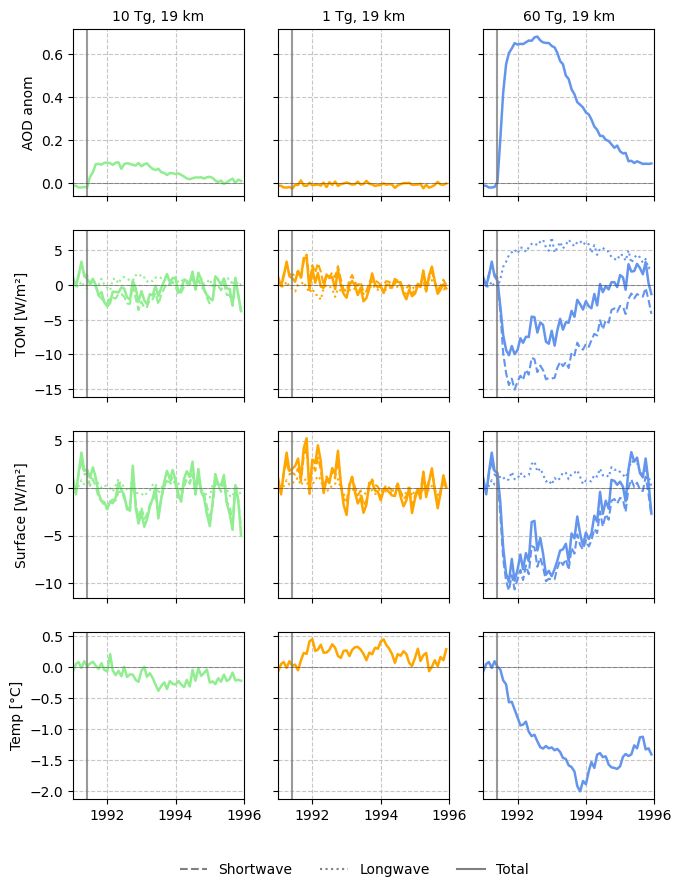

In [42]:
experiments = [
   # (aod_anom, netswtom_anom, netlwtom_anom, total_tom_19, netswsurf_anom, netlwsurf_anom, total_surf_19, temp_19_anom, "deepskyblue", "10 Tg 19 km (All)"),
    (aod_anom_19_c, netswtom_19_c_anom, netlwtom_19_c_anom, total_tom_19_c, netswsurf_19_c_anom, netlwsurf_19_c_anom, total_surf_19_c, t_anom_19_c, "lightgreen", "10 Tg, 19 km"),
   # (aod_anom_22,netswtom_22_anom, netlwtom_22_anom, total_tom_22,  netswsurf_22_anom, netlwsurf_22_anom, total_surf_22, t_anom_22, "mediumseagreen", "10 Tg, 22 km"),
   # (aod_anom_1825,netswtom_1825_anom, netlwtom_1825_anom, total_tom_1825, netswsurf_1825_anom, netlwsurf_1825_anom, total_surf_1825, t_anom_1825, "mediumorchid", "10 Tg, 18-25 km"),
   # (aod_anom_24,netswtom_24_anom, netlwtom_24_anom, total_tom_24, netswsurf_24_anom, netlwsurf_24_anom, total_surf_24, t_anom_24, "green", "17 Tg, 24 km"),
   # (aod_anom_1825_17tg,netswtom_1825_17tg_anom, netlwtom_1825_17tg_anom, total_tom_1825_17tg, netswsurf_1825_17tg_anom, netlwsurf_1825_17tg_anom, total_surf_1825_17tg, t_anom_1825_17tg, "blueviolet", "17 Tg, 18-25 km"),
   # (aod_anom_1pr,netswtom_1pr_anom, netlwtom_1pr_anom, total_tom_1pr, netswsurf_1pr_anom, netlwsurf_1pr_anom, total_surf_1pr, t_anom_1pr, "hotpink", "10 Tg, 19 km (1% SO₄)"),
    (aod_anom_1tg,netswtom_1tg_anom, netlwtom_1tg_anom, total_tom_1tg, netswsurf_1tg_anom, netlwsurf_1tg_anom, total_surf_1tg, t_anom_1tg, "orange", "1 Tg, 19 km"),
    (aod_anom_60tg,netswtom_60tg_anom, netlwtom_60tg_anom, total_tom_60tg, netswsurf_60tg_anom, netlwsurf_60tg_anom, total_surf_60tg, t_anom_60tg, "cornflowerblue", "60 Tg, 19 km")
]

eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
start_date    = cftime.DatetimeNoLeap(1991, 1, 1)
end_date      = cftime.DatetimeNoLeap(1996, 1, 1)

xticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in range(1991, 1997)]
xtick_labels = [str(y) for y in range(1991, 1997)]

num_exps = len(experiments)

fig, axes = plt.subplots(4, num_exps, figsize=(num_exps * 2.5, 10), sharex=True, sharey='row')

for i, (aod, sw_t, lw_t, tot_t, sw_s, lw_s, tot_s, tmp, color, name) in enumerate(experiments):
    ax_aod = axes[0, i]
    aod.plot(ax=ax_aod, color=color, lw=1.8)
    ax_aod.set_title("")

    ax_aod.set_title(name, fontsize=10)

    ax_tom = axes[1, i]
    sw_t.plot(ax=ax_tom, color=color, ls="--")
    lw_t.plot(ax=ax_tom, color=color, ls=":")
    tot_t.plot(ax=ax_tom, color=color, ls="-", lw=1.8)

    
    ax_surf = axes[2, i]
    sw_s.plot(ax=ax_surf, color=color, ls="--")
    lw_s.plot(ax=ax_surf, color=color, ls=":")
    tot_s.plot(ax=ax_surf, color=color, ls="-", lw=1.8)
    ax_surf.set_title("") 
    
    ax_temp = axes[3, i]
    tmp.plot(ax=ax_temp, color=color, lw=1.8)
    ax_temp.set_title("")

    for ax in [ax_aod, ax_tom, ax_surf, ax_temp]:
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.axvline(x=eruption_date, color="gray", linestyle="-", lw=1.5, alpha=0.8)
        
        ax.axhline(0, color="black", lw=0.6, alpha=0.4)
        ax.set_xlabel("")
        ax.set_ylabel("") 
        ax.set_xlim(start_date, end_date)
axes[0, 0].set_ylabel("AOD anom", fontsize=10)
axes[1, 0].set_ylabel("TOM [W/m²]", fontsize=10)
axes[2, 0].set_ylabel("Surface [W/m²]", fontsize=10)
axes[3, 0].set_ylabel("Temp [°C]", fontsize=10)

custom_lines = [Line2D([0], [0], color='gray', ls='--'),
                Line2D([0], [0], color='gray', ls=':'),
                Line2D([0], [0], color='gray', ls='-')]
fig.legend(custom_lines, ['Shortwave', 'Longwave', 'Total'], 
           loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.02))

plt.show()

In [40]:
t_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/TS_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in t_19['time'].values])
t_19 = t_19.assign_coords(time=shifted_time_19)
t_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/TS_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in t_19_c['time'].values])
t_19_c = t_19_c.assign_coords(time=shifted_time_19_c)
t_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/TS_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in t_22['time'].values])
t_22 = t_22.assign_coords(time=shifted_time_22)
t_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/TS_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in t_24['time'].values])
t_24 = t_24.assign_coords(time=shifted_time_24)
t_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/TS_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in t_1825_17tg['time'].values])
t_1825_17tg = t_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
t_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/TS_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in t_1825['time'].values])
t_1825 = t_1825.assign_coords(time=shifted_time_1825)
t_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/TS_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in t_1tg['time'].values])
t_1tg = t_1tg.assign_coords(time=shifted_time_1tg)
t_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/TS_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in t_1pr['time'].values])
t_1pr = t_1pr.assign_coords(time=shifted_time_1pr)
t_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/TS_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in t_60tg['time'].values])
t_60tg = t_60tg.assign_coords(time=shifted_time_60tg)